# Fetch Data

In [3]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("zefang-liu/phishing-email-dataset")

# Convert to pandas directly
df = ds["train"].to_pandas()

print(df.shape)
print(df.head())

README.md:   0%|          | 0.00/616 [00:00<?, ?B/s]

Phishing_Email.csv:   0%|          | 0.00/52.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18650 [00:00<?, ? examples/s]

(18650, 3)
   Unnamed: 0                                         Email Text  \
0           0  re : 6 . 1100 , disc : uniformitarianism , re ...   
1           1  the other side of * galicismos * * galicismo *...   
2           2  re : equistar deal tickets are you still avail...   
3           3  \nHello I am your hot lil horny toy.\n    I am...   
4           4  software at incredibly low prices ( 86 % lower...   

       Email Type  
0      Safe Email  
1      Safe Email  
2      Safe Email  
3  Phishing Email  
4  Phishing Email  


# EDA

In [14]:
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [15]:
df['is_scam'] = df['Email Type'].map({'Phishing Email': 1, 'Safe Email': 0})
df.drop(columns=["Email Type"], inplace=True)
df.head()


,Email Text,is_scam
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,\nHello I am your hot lil horny toy.\n I am...,1
4,software at incredibly low prices ( 86 % lower...,1


In [16]:
# Change Email Text to be 'email_text'
df.rename(columns={'Email Text': 'email_text'}, inplace=True)
df.head()

,email_text,is_scam
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,\nHello I am your hot lil horny toy.\n I am...,1
4,software at incredibly low prices ( 86 % lower...,1


In [38]:
print(len(df))

18650


In [23]:
# check data balance
print(df['is_scam'].value_counts())

is_scam
0    11322
1     7328
Name: count, dtype: int64


### Check for Text Length Distribution

        text_length                                                          \
              count         mean            std  min    25%    50%      75%   
is_scam                                                                       
0           11322.0  3493.008391  160168.024661  5.0  444.0  994.5  2029.75   
1            7312.0  1613.924508    3352.191512  1.0  355.0  732.0  1568.75   

                    word_count                                              \
                max      count        mean           std  min   25%    50%   
is_scam                                                                      
0        17036692.0    11322.0  685.870253  33160.236982  1.0  79.0  179.0   
1          129635.0     7312.0  301.848058    570.172160  0.0  68.0  136.0   

                           
           75%        max  
is_scam                    
0        389.0  3527576.0  
1        290.0    11625.0  


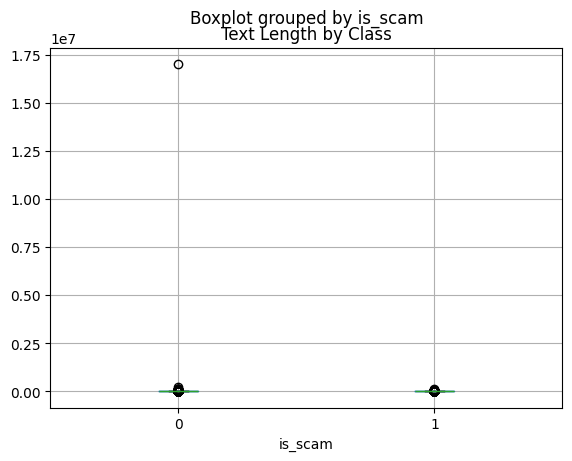

Too short: 544 rows
Too long:  3160 rows


In [32]:
import matplotlib.pyplot as plt
# check text length distribution
df['text_length'] = df['email_text'].str.len()
df["word_count"]  = df["email_text"].str.split().str.len()

# describe text length and word count
print(df.groupby("is_scam")[["text_length", "word_count"]].describe())

# visualize text length distribution
df.boxplot(column="text_length", by="is_scam")

plt.title("Text Length by Class")
plt.show()

# Flag suspicious lengths
too_short = df[df["word_count"] < 3]
too_long  = df[df["word_count"] > 500]
print(f"Too short: {len(too_short)} rows")
print(f"Too long:  {len(too_long)} rows")

In [37]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df["email_text"].fillna("").tolist(), show_progress_bar=True)

# Find pairs with similarity > 0.95
sim_matrix = cosine_similarity(embeddings)
np.fill_diagonal(sim_matrix, 0)   # ignore self-similarity
near_dupes = np.where(sim_matrix > 0.95)
print(f"Near-duplicate pairs: {len(near_dupes[0]) // 2}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/583 [00:00<?, ?it/s]

Near-duplicate pairs: 157799


In [46]:
# Method 1 — Cleanlab (best tool for this)
# pip install cleanlab
from cleanlab.classification import CleanLearning
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
np.random.seed(42)
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["email_text"].fillna("").tolist())
y = df["is_scam"].values

cl = CleanLearning(LogisticRegression())
label_issues = cl.find_label_issues(X, y)

# Rows cleanlab thinks are mislabeled
suspected_noise = df[label_issues["is_label_issue"]]
print(f"Suspected mislabeled rows: {len(suspected_noise)}")
print(suspected_noise[["email_text", "is_scam"]].head(28))

Suspected mislabeled rows: 32
                                              email_text  is_scam
1121   fortune ' s power 50 dear ms . kitchen , you a...        0
2066   us news archive @ ft . com reliable country in...        0
2786   it ' s not the same without your smiling face ...        0
2945   your valpak . com " print later " link below i...        0
3182   \nBIG 12 OR BUST\nÂ \nThis\nweekend you can se...        0
5918   You are receiving this email because you signe...        0
5920   URL: 1983@http://diveintomark.org/\nDate: 2002...        0
6738   registration welcome email thank you for regis...        0
7085   DivX News (Number 21, 2002-07-26)\n===========...        0
8156          can you work you legalies into this form .        0
10557  london visit hi maureen how many days are you ...        0
10633  registration welcome email thank you for regis...        0
11440  research get - together at sandeep kohli ' s n...        0
11701  > This is getting better and better. Yo

In [43]:
for idx in suspected_noise.index:
    print(f"\nRow {idx} - Label: {df.loc[idx, 'is_scam']}")
    print(df.loc[idx, "email_text"])


Row 1121 - Label: 0
fortune ' s power 50 dear ms . kitchen , you are a strong contender to be on fortune ? s list of the 50 most powerful women in business this year . please take a moment to make our powerful women issue as engaging and fun for our magazine readers and website users as it has been for us . by answering the following questions , you can help us to get a better sense of you and your busy life . please e - mail the information back to alynda _ wheat @ fortunemail . com by the end of the day on september 14 . we realize this doesn ? t give you much time , but this will go a long way to making our coverage more accurate and enjoyable . sincerely , vera titunik senior editor fortune date of birth where did you go to college ? graduate school ? please provide the names of your educational institutions , indicating graduate or undergraduate level . what was your undergraduate major ? how long have you been at your company ? how many times have you changed jobs or been promot

### EDA Findings
1. data contains 18650 samples 
2. Data Distribution {"Scam": 7328 , "Save": 11322 } -> imballance
3. Suspected mislabeled rows: 32 -> need to drop

### Save to Csv

,email_text,is_scam,text_length,word_count
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0,1030.0,230.0
1,the other side of * galicismos * * galicismo *...,0,479.0,91.0
2,re : equistar deal tickets are you still avail...,0,1245.0,305.0
3,\nHello I am your hot lil horny toy.\n I am...,1,688.0,96.0
4,software at incredibly low prices ( 86 % lower...,1,441.0,91.0


In [48]:
saved_df = df.drop(columns=["text_length", "word_count"])
saved_df.to_csv("phishing_email_dataset.csv", index=False)